
# Colony matters: How density shapes predator access in two Antarctic fur seal (*Arctocephalus gazella*) colonies

**Authors:** Johannes Bartl, Ane Liv Berthelsen, Alexander Winterl, Cameron Fox-Clarke, Jaume Forcada, Rebecca Nagel, Joseph I. Hoffman, Ben Fabry

---

## Analysis Overview

This notebook details the data processing and statistical analysis workflow used to generate the results and figures presented in the manuscript.

### 1. Data Preparation & Filtering
The analysis begins with raw detection counts retrieved from the neural network. To ensure data quality and consistency, the following filters were applied prior to analysis:
* **Temporal Filtering:** Data is restricted to daylight hours (**09:00 – 17:00**) to ensure consistent visibility.
* **Image Quality Control:** A **Laplacian Variance** filter was applied to automatically exclude images compromised by environmental factors, such as heavy fog or water droplets on the lens.

### 2. Key Results & Figures
We perform the primary analyses described in the manuscript, corresponding to the following figures:

* **(a) Temporal trends in abundance at Special Study Beach**  (Figure 2)

* **(b) Abundance ratios of birds to pups between colonies** (Figure 3)

* **(c) Demographic patterns in seal density** (Figure 4)

* **(d) Spatial associations between birds and pups** (Figure 5)

In [1]:
# --- Standard Library ---
import glob
import math
import os
from pathlib import Path
from typing import List, Optional
from xml.dom.minidom import parse

# --- Third Party: Data & Math ---
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.spatial import Voronoi, QhullError
from scipy.stats import gaussian_kde
import torch
import yaml

# --- Third Party: Geospatial & Geometry ---
import cartopy.crs as ccrs
import contourpy
import geopandas as gpd
from shapely.geometry import GeometryCollection, MultiPolygon, Point, Polygon
from shapely.ops import unary_union

# --- Third Party: Image, Vision & AI ---
import cameratransform
from cameratransform import moveDistance
import clickpoints
from PIL import Image
from ultralytics import YOLO

# --- Third Party: Plotting & Visualization ---
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.dates as mpl_dates
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as patches
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch, Rectangle
from matplotlib.transforms import ScaledTranslation

# --- Utilities ---
from tqdm.auto import tqdm  # Automatically handles notebook/console bars

# --- Jupyter Magic ---
%matplotlib inline

### Helper functions

In [2]:
def kde_outline_from_hist2d_v2(x, y, prob=0.99, resolution=1.0, 
                                 sigma=1, padding=0.1, 
                                 return_shapely=False):

    x = np.asarray(x)
    y = np.asarray(y)
    
    # 0. Clean Data
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    
    if x.size == 0:
        return [], None if return_shapely else []

    # 1. Determine Data Extent
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    
    # 2. Apply Padding to the Extent
    # We expand the bounds so the KDE doesn't get cut off at the exact data edge
    w = xmax - xmin
    h = ymax - ymin
    
    xmin -= padding * w
    xmax += padding * w
    ymin -= padding * h
    ymax += padding * h
    
    # 3. Calculate Number of Bins based on Resolution
    # Rule: Bin Count = Total Distance / Resolution
    # e.g., if Range is 20m and Resolution is 1m, we need 20 bins.
    x_range = xmax - xmin
    y_range = ymax - ymin
    
    n_bins_x = max(1, int(np.ceil(x_range / resolution)))
    n_bins_y = max(1, int(np.ceil(y_range / resolution)))
    
    # 4. Create the 2D Histogram (The Grid)
    # H represents the raw count of points in each grid cell
    H, xedges, yedges = np.histogram2d(x, y, bins=[n_bins_x, n_bins_y], 
                                       range=[[xmin, xmax], [ymin, ymax]])
    

    # 6. Apply Gaussian Smoothing
    Hs = gaussian_filter(H, sigma=sigma, mode='constant')
    
    vals = Hs.ravel()
    total = vals.sum()
    order = np.argsort(vals)[::-1]
    cum = np.cumsum(vals[order])

    k = np.searchsorted(cum, 0.99 * total)
    k = min(max(int(k), 0), vals.size - 1)
    thresh = float(vals[order][k])

    # guard against degenerate levels
    vmax = float(vals[order][0])
    eps = np.finfo(float).eps
    if thresh <= 0:
        thresh = max(vmax * 1e-12, eps)
    if thresh >= vmax:
        thresh = vmax - max(vmax * 1e-12, eps)

    # --- 2) grid coordinates (bin centers) ---
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])

    # histogram2d gives H shape (nx, ny), so transpose to (ny, nx)
    Z = Hs.T

    # --- 3) contour lines at that threshold ---
    cg = contourpy.contour_generator(x=xc, y=yc, z=Z, name="serial")
    lines = cg.lines(thresh)   # list of (N,2) arrays in (x,y)
    
    rings = [L for L in lines if len(L) >= 4 and np.allclose(L[0], L[-1])]
    mp = rings_to_multipolygon(rings)
    return H,Hs,lines,rings,mp

In [3]:
def rings_to_multipolygon(rings, close_tol=1e-9, fix_invalid=True):
    polys = []

    for r in rings:
        r = np.asarray(r)
        if r.shape[0] < 4:
            continue

        # ensure ring is closed
        if not np.allclose(r[0], r[-1], atol=close_tol, rtol=0):
            r = np.vstack([r, r[0]])

        p = Polygon(r)
        if p.is_empty or p.area <= 0:
            continue

        if fix_invalid and not p.is_valid:
            # common fix for self-intersections
            p = p.buffer(0)

        if not p.is_empty and p.area > 0:
            polys.append(p)

    if not polys:
        return MultiPolygon([])

    u = unary_union(polys)

    # keep polygonal parts only
    if isinstance(u, GeometryCollection):
        u = unary_union([g for g in u.geoms if g.geom_type in ("Polygon", "MultiPolygon")])

    # force MultiPolygon return
    if u.geom_type == "Polygon":
        return MultiPolygon([u])
    if u.geom_type == "MultiPolygon":
        return u

    return MultiPolygon([])

In [4]:
def plot_ge_dataset(ds, ax, elements=None):
    """
    ds = {"png": ..., "kml": ..., "cdb": ..., "name": ...}
    elements: list like ["rock", "water"]; if None -> all keys in COLORS
    """
    elements = list(elements) if elements is not None else list(COLORS.keys())

    img = plt.imread(ds["png"])
    marker, fov, polys = read_cdb_layers(ds["cdb"], wanted_layers=elements)

    # Fit pixel->lon/lat
    kml_corners = read_kml_corners(ds["kml"])
    marker[["lon", "lat"]] = kml_corners[["lon", "lat"]].to_numpy()
    pixel2ll = fit_pixel2lonlat(marker)

    # Extents
    extent_image = compute_image_extent(img, pixel2ll)
    extent = compute_fov_extent(fov.iloc[0], pixel2ll)

    # Draw
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.imshow(img, origin="upper", extent=extent_image, transform=ccrs.PlateCarree(), zorder=0)

    # Plot only requested-and-present layers
    for layer in elements:
        if layer in polys and layer in COLORS:
            plot_polygons(polys[layer], color=COLORS[layer], ax=ax, pixel2ll_func=pixel2ll, alpha=ALPHA)

In [5]:
def read_cdb_layers(cdb_path, wanted_layers):
    with clickpoints.DataFile(cdb_path) as cdb:
        marker = pd.DataFrame([[m.x, m.y, m.id] for m in cdb.getMarkers(type="marker")],
                              columns=["x","y","id"])
        fov = pd.DataFrame([[m.x, m.y, m.x+m.width, m.y+m.height, m.id]
                            for m in cdb.getRectangles(type="fov")],
                           columns=["x1","y1","x2","y2","id"])
        polys = {}
        for layer in wanted_layers:
            try:
                df = polygon_points_df(cdb, layer)
                if not df.empty:
                    polys[layer] = df
            except clickpoints.MarkerTypeDoesNotExist:
                # layer not present in this CDB -> skip
                continue
    return marker, fov, polys

def polygon_points_df(cdb, poly_type, id_col="poly_id"): 
    return pd.DataFrame(
        [(pid, x, y) for pid, poly in enumerate(cdb.getPolygons(type=poly_type), 1) for x, y in poly.points],
        columns=[id_col, "x", "y"]
    )
def read_kml_corners(kml_path):
    doc = parse(kml_path)
    # Take the first coordinates block (adjust if you need a specific placemark)
    coords_txt = doc.getElementsByTagName("coordinates")[0].firstChild.nodeValue.strip()
    pts = [tuple(map(float, c.split(",")[:2])) for c in coords_txt.split()]
    # Return as DataFrame with lon/lat in a known order
    df = pd.DataFrame(pts, columns=["lon", "lat"])
    return df

def fit_pixel2lonlat(marker):
    """
    Given a DataFrame `marker` with columns ['x','y','lon','lat'] for at least
    3 (but here 4) non-collinear control points, fit an affine map
       [lon, lat]^T = M · [x, y, 1]^T
    and return a function pixel2lonlat(x, y) -> (lon, lat).
    """
    # 1) Build design matrix A and target vectors
    pts_px     = marker[['x','y']].to_numpy()       # shape (4,2)
    pts_lonlat = marker[['lon','lat']].to_numpy()   # shape (4,2)
    A = np.hstack([pts_px, np.ones((pts_px.shape[0],1))])  # (4×3)

    # 2) Solve separately for lon and lat coefficients
    coeffs_lon = np.linalg.lstsq(A, pts_lonlat[:,0], rcond=None)[0]  # [a, b, c]
    coeffs_lat = np.linalg.lstsq(A, pts_lonlat[:,1], rcond=None)[0]  # [d, e, f]

    a, b, c = coeffs_lon
    d, e, f = coeffs_lat

    # 3) Return the mapping function
    def pixel2lonlat(x, y):
        """
        Map pixel coords x, y (scalar or array-like) to (lon, lat).
        """
        x = np.asarray(x)
        y = np.asarray(y)
        lon = a*x + b*y + c
        lat = d*x + e*y + f
        return lon, lat

    return pixel2lonlat

def plot_polygons(poly_df, color, ax, pixel2ll_func, zorder=2, alpha=0.5, edgecolor=None):
    """
    Plot polygons from a DataFrame with columns ['poly_id','x','y'] on a Cartopy axis.
    - poly_df: DataFrame of all polygon vertices
    - color: fill color for polygons
    - ax: Cartopy GeoAxes
    - pixel2ll_func: function mapping pixel x,y → lon,lat
    - zorder: drawing order
    - alpha: polygon transparency
    - edgecolor: border color
    """
    for pid, group in poly_df.groupby('poly_id'):
        # extract pixel coords
        xs = group['x'].values
        ys = group['y'].values
        # convert to lon/lat
        lons, lats = pixel2ll_func(xs, ys)
        # create a shapely polygon
        poly = Polygon(zip(lons, lats))
        # add to axis
        ax.add_geometries([poly], crs=ccrs.PlateCarree(),
                          facecolor=color, edgecolor=edgecolor,
                          alpha=alpha, zorder=zorder)
def compute_image_extent(img, pixel2ll):
    h, w = img.shape[:2]
    corners_px = np.array([[0,0], [w,0], [w,h], [0,h]])
    lons, lats = pixel2ll(corners_px[:,0], corners_px[:,1])
    return [lons.min(), lons.max(), lats.min(), lats.max()]

def compute_fov_extent(fov_row, pixel2ll):
    corners_fov_px = np.array([
        [fov_row["x1"], fov_row["y1"]],
        [fov_row["x1"], fov_row["y2"]],
        [fov_row["x2"], fov_row["y1"]],
        [fov_row["x2"], fov_row["y2"]],
    ])
    lons, lats = pixel2ll(corners_fov_px[:, 0], corners_fov_px[:, 1])
    return [lons.min(), lons.max(), lats.min(), lats.max()]
def add_scalebar(ax, length_m, label=None, location='lower left',
                 pad_frac=0.04, bar_frac=0.25, linewidth=3, color='k', text_kw=None):
    """
    Draw a horizontal scale bar of `length_m` meters on a Cartopy GeoAxes.
    - location: 'lower left' | 'lower right' | 'upper left' | 'upper right'
    - pad_frac: padding from the edges as a fraction of current extent
    - bar_frac: bar length as a fraction of axis width if label is too long; here we use meters directly
    """
    if text_kw is None:
        text_kw = dict(ha='center', va='top', fontsize=9, color=color)

    # Use the current geographic extent
    lonmin, lonmax, latmin, latmax = ax.get_extent(ccrs.PlateCarree())
    dlon_extent = lonmax - lonmin
    dlat_extent = latmax - latmin

    # Anchor point near the chosen corner
    xpad = pad_frac * dlon_extent
    ypad = pad_frac * dlat_extent

    if 'left' in location:
        x0 = lonmin + xpad
        ha_line = 1.0  # text center above mid
    else:
        x0 = lonmax - xpad
        ha_line = -1.0

    if 'lower' in location:
        y0 = latmin + ypad
        va_line = 1.0
        text_va = 'bottom'
    else:
        y0 = latmax - ypad
        va_line = -1.0
        text_va = 'top'

    # Convert desired meters to degrees of longitude at the anchor latitude
    m_per_deg = _meters_per_deg_lon(y0)
    dlon = (length_m / m_per_deg)

    # For right-side anchors, draw bar to the left
    if 'right' in location:
        x1 = x0 - dlon
    else:
        x1 = x0 + dlon

    # Draw the bar
    ax.plot([x0, x1], [y0, y0], transform=ccrs.PlateCarree(), color=color, linewidth=linewidth, solid_capstyle='butt',zorder=100)


    # Label
    if label is None:
        label = f"{int(length_m)} m" if length_m < 1000 else f"{int(round(length_m/1000))} km"
    ax.text((x0 + x1)/2, y0 + va_line*(0.02*dlat_extent),
            label, transform=ccrs.PlateCarree(),
            ha='center', va=text_va, **{k:v for k,v in text_kw.items() if k not in ('ha','va')},zorder=100)
    
def _meters_per_deg_lon(lat_deg):
    """Approx meters per degree of longitude at latitude (better than cos-approx)."""
    φ = np.deg2rad(lat_deg)
    # NOAA/NGA formula (WGS-84) for longitude length per degree
    return (111412.84*np.cos(φ) - 93.5*np.cos(3*φ) + 0.118*np.cos(5*φ))

def multipolygon_to_gps(cam, geom_xy, z_plane=0.0, fix_invalid=True):
    """
    Convert a shapely Polygon/MultiPolygon in camera-local XY (meters)
    into a shapely MultiPolygon in (lat, lon) by applying cam.gpsFromSpace.

    Returns: shapely MultiPolygon (may be empty)
    """
    if geom_xy is None or geom_xy.is_empty:
        return MultiPolygon([])

    if geom_xy.geom_type == "Polygon":
        polys = [geom_xy]
    elif geom_xy.geom_type == "MultiPolygon":
        polys = list(geom_xy.geoms)
    elif geom_xy.geom_type == "GeometryCollection":
        polys = [g for g in geom_xy.geoms if g.geom_type == "Polygon"]
    else:
        raise TypeError(f"Expected Polygon/MultiPolygon, got {geom_xy.geom_type}")

    out = []
    for p in polys:
        ext = _ring_xy_to_latlon(cam, p.exterior.coords, z_plane)
        if ext is None or ext.shape[0] < 4:
            continue

        holes = []
        for r in p.interiors:
            h = _ring_xy_to_latlon(cam, r.coords, z_plane)
            if h is not None and h.shape[0] >= 4:
                holes.append(h)

        q = Polygon(ext, holes=holes)

        if fix_invalid and (not q.is_valid):
            q = q.buffer(0)

        if not q.is_empty and q.area > 0:
            out.append(q)

    if not out:
        return MultiPolygon([])

    u = unary_union(out)

    if isinstance(u, GeometryCollection):
        u = unary_union([g for g in u.geoms if g.geom_type in ("Polygon", "MultiPolygon")])

    if u.is_empty:
        return MultiPolygon([])
    if u.geom_type == "Polygon":
        return MultiPolygon([u])
    if u.geom_type == "MultiPolygon":
        return u

    return MultiPolygon([])

def _ring_xy_to_latlon(cam, ring_coords, z_plane):
    """
    ring_coords: sequence of (x,y) from shapely (usually already closed)
    returns: Nx2 array of (lat, lon)
    """
    pts = np.asarray(ring_coords, dtype=float)
    if pts.ndim != 2 or pts.shape[0] < 4:
        return None

    P3 = np.column_stack([pts[:, 0], pts[:, 1], np.full(pts.shape[0], z_plane, dtype=float)])
    gps = np.asarray(cam.gpsFromSpace(P3), dtype=float)  # Nx3: lon, lat, alt
    latlon = gps[:, [1, 0]]  # <-- swap to (lat, lon)
    return latlon

def overlap_percent(a, b, mode="iou"):
    """
    a, b: shapely Polygon/MultiPolygon
    mode:
      - "iou"      : 100 * area(A∩B) / area(A∪B)        (Jaccard / IoU)
      - "of_a"     : 100 * area(A∩B) / area(A)          (how much of A is covered by B)
      - "of_b"     : 100 * area(A∩B) / area(B)          (how much of B is covered by A)
      - "min"      : 100 * area(A∩B) / min(area(A),area(B))
      - "max"      : 100 * area(A∩B) / max(area(A),area(B))
    """
    if a is None or b is None or a.is_empty or b.is_empty:
        return 0.0

    inter = a.intersection(b)
    inter_area = inter.area
    if inter_area <= 0:
        return 0.0

    area_a = a.area
    area_b = b.area

    if mode == "of_a":
        return 0.0 if area_a == 0 else 100.0 * inter_area / area_a
    if mode == "of_b":
        return 0.0 if area_b == 0 else 100.0 * inter_area / area_b
    if mode == "min":
        denom = min(area_a, area_b)
        return 0.0 if denom == 0 else 100.0 * inter_area / denom
    if mode == "max":
        denom = max(area_a, area_b)
        return 0.0 if denom == 0 else 100.0 * inter_area / denom

    # default: IoU
    union_area = a.union(b).area
    return 0.0 if union_area == 0 else 100.0 * inter_area / union_area

### Load data (get from Zenodo [DOI:])

In [6]:
fwb = pd.read_csv("FWB.csv")
ssb = pd.read_csv("SSB.csv")

In [7]:
cam_ssb = cameratransform.load_camera("map/ssb_cam.ct")
cam_fwb = cameratransform.load_camera("map/fwb_cam.ct")

In [8]:
os.makedirs("figures",exist_ok=True)

### Setup: colors, labels, path

In [9]:
colors = {
    'female': '#1F77B4',
    'male': '#FF7F0E',
    'pup': '#2CA02C',
    'giant petrel': '#9467bd', 
    'skua': '#8C564B',
    'sheathbill': '#e377c2', 
    'fwb': 'salmon',
    'ssb': '#5254A3'
}
labels = {
    'male' : 'adult male',
    'female' : 'adult female',
    'pup' : 'pup',
    'giant petrel' : 'giant petrel',
    'sheathbill' : 'snowy sheathbill',
    'skua' : 'brown skua',
}

fontsize = 11

###  (a) Temporal trends in abundance at Special Study Beach

In [10]:
def daily_max_abundance(df, time_col="timestamp", class_col="class", group_col="filename"):
    # 1. extract date
    df['date'] = pd.to_datetime(df[time_col]).dt.date

    # 2. count detections per image (or per filename) per class per day
    counts = (
        df
        .groupby(['date', group_col, class_col])
        .size()
        .reset_index(name='count')
    )

    # 3. for each date & class, take the maximum count across images
    daily_max = (
        counts
        .groupby(['date', class_col])['count']
        .max()
        .unstack(fill_value=0)
    )
    return daily_max

In [11]:
ssb_abundance = daily_max_abundance(df=ssb)
fwb_abundance = daily_max_abundance(df=fwb)

In [12]:
first_born_pup_ssb = pd.Timestamp("2020-11-22")
first_born_pup_fwb = pd.Timestamp("2020-11-18")

In [13]:
# ssb_abundance_99 = daily_max_abundance(df=ssb_99)
# fwb_abundance_99 = daily_max_abundance(df=fwb_99)

#### SSB

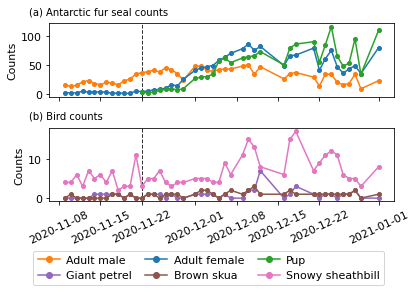

In [14]:
# Convert index to pandas Timestamp to prevent "Cannot compare Timestamp with date" error
ssb_abundance.index = pd.to_datetime(ssb_abundance.index)

# --- Plotting Setup ---
fig, axs = plt.subplots(figsize=(5.9, 4.1), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0.15)

groups = [
    ["male", "female", "pup"],
    ["giant petrel", "skua", "sheathbill"]
]
panel_titles = [
    "(a) Antarctic fur seal counts", 
    "(b) Bird counts"
]

# --- Main Plot Loop ---
for i, (ax, species_list) in enumerate(zip(axs, groups)):
    
    # Add vertical dashed line (zorder=0 puts it behind the lines)
    ax.axvline(first_born_pup_ssb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)

    for animal in species_list:
        x_data = ssb_abundance.index
        y_data = ssb_abundance[animal]
        
        # SPECIAL CASE: Filter Pups using the now compatible Timestamp
        if animal == 'pup':
            mask = x_data >= first_born_pup_ssb
            x_data = x_data[mask]
            y_data = y_data[mask]

        ax.plot(
            x_data, y_data,
            color=colors[animal], 
            marker='o', 
            markersize=4,
            label=labels[animal].capitalize()
        )

    # Styling
    ax.set_ylabel("Counts", fontsize=fontsize)
    
    # Panel Label
    trans = ax.transAxes + ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, panel_titles[i], transform=trans, fontsize='medium', va='bottom')

# --- Formatting ---
axs[0].tick_params(labelbottom=False)
axs[1].tick_params(axis='x', rotation=25, labelsize=fontsize)
axs[0].tick_params(axis='y', labelsize=fontsize)
axs[1].tick_params(axis='y', labelsize=fontsize)

# --- Legend ---
legend_order = ["male","giant petrel", "female", "skua", "pup", "sheathbill"]
handles = [Line2D([0], [0], marker='o', color=colors[a], linestyle='-') for a in legend_order]
labels_ = [labels[a].capitalize() for a in legend_order]

fig.legend(
    handles, labels_,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    fontsize=fontsize,
    columnspacing=1.2, 
    handletextpad=0.6, 
    borderaxespad=0.0,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("figures/figure2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

#### FWB

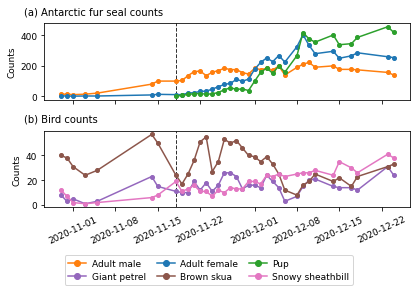

In [15]:

# Convert index to pandas Timestamp to prevent "Cannot compare Timestamp with date" error
fwb_abundance.index = pd.to_datetime(fwb_abundance.index)

# --- Plotting Setup ---
fontsize = 9
fig, axs = plt.subplots(figsize=(5.9, 4.1), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0.15)

groups = [
    ["male", "female", "pup"],
    ["giant petrel", "skua", "sheathbill"]
]
panel_titles = [
    "(a) Antarctic fur seal counts", 
    "(b) Bird counts"
]

# --- Main Plot Loop ---
for i, (ax, species_list) in enumerate(zip(axs, groups)):
    
    # Add vertical dashed line (zorder=0 puts it behind the lines)
    ax.axvline(first_born_pup_fwb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)

    for animal in species_list:
        x_data = fwb_abundance.index
        y_data = fwb_abundance[animal]
        
        # SPECIAL CASE: Filter Pups using the now compatible Timestamp
        if animal == 'pup':
            mask = x_data >= first_born_pup_fwb
            x_data = x_data[mask]
            y_data = y_data[mask]

        ax.plot(
            x_data, y_data,
            color=colors[animal], 
            marker='o', 
            markersize=4,
            label=labels[animal].capitalize()
        )

    # Styling
    ax.set_ylabel("Counts", fontsize=fontsize)
    
    # Panel Label
    trans = ax.transAxes + ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, panel_titles[i], transform=trans, fontsize='medium', va='bottom')

# --- Formatting ---
axs[0].tick_params(labelbottom=False)
axs[1].tick_params(axis='x', rotation=25, labelsize=fontsize)
axs[0].tick_params(axis='y', labelsize=fontsize)
axs[1].tick_params(axis='y', labelsize=fontsize)

# --- Legend ---
legend_order = ["male","giant petrel", "female", "skua", "pup", "sheathbill"]
handles = [Line2D([0], [0], marker='o', color=colors[a], linestyle='-') for a in legend_order]
labels_ = [labels[a].capitalize() for a in legend_order]

fig.legend(
    handles, labels_,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    fontsize=fontsize,
    columnspacing=1.2, 
    handletextpad=0.6, 
    borderaxespad=0.0,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
# plt.savefig("figures/figure2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

### (b) Abundance ratios of birds to pups between colonies

--- Median Values ---
Giant petrel: FWB=0.1282, SSB=0.0161
  FWB 95% CI: [0.0582, 0.4919]
  SSB 95% CI: [0.0000, 0.0303]
Brown skua: FWB=0.2222, SSB=0.0200
  FWB 95% CI: [0.0732, 1.1183]
  SSB 95% CI: [0.0154, 0.0312]
Snowy sheathbill: FWB=0.1495, SSB=0.1667
  FWB 95% CI: [0.0988, 0.2766]
  SSB 95% CI: [0.1176, 0.1899]


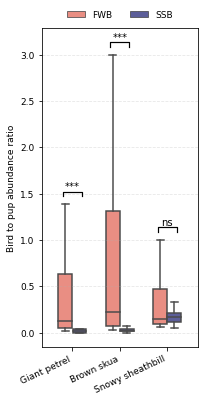

In [16]:
bird_keys = ["giant petrel", "skua", "sheathbill"]

ssb_abundance.index = pd.to_datetime(ssb_abundance.index)
fwb_abundance.index = pd.to_datetime(fwb_abundance.index)

# mask: pups after first born pup
mask_pred = ssb_abundance.index > first_born_pup_ssb
mask_fwb = fwb_abundance.index > first_born_pup_fwb

plot_data = []

for species in bird_keys:
    # Get the display name from the labels dict (e.g., "Brown skua")
    display_name = labels[species].capitalize()
    
    # SSB Data
    subset_pred = ssb_abundance[mask_pred].copy()
    ratios_pred = subset_pred[species] / subset_pred['pup']
    for r in ratios_pred:
        plot_data.append({'Species': display_name, 'Ratio': r, 'Dataset': 'SSB'})
        
    # FWB Data
    subset_fwb = fwb_abundance[mask_fwb].copy()
    ratios_fwb = subset_fwb[species] / subset_fwb['pup']
    for r in ratios_fwb:
        plot_data.append({'Species': display_name, 'Ratio': r, 'Dataset': 'FWB'})


df_plot = pd.DataFrame(plot_data)
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=['Ratio'])

y_range = df_plot['Ratio'].max() - df_plot['Ratio'].min()

# --- 3. Plotting ---
plt.figure(figsize=(2.95, 6)) # 5.9/2 width
flier_props = dict(marker='.', markerfacecolor='black', markersize=4, linestyle='none')

# plt.yscale('log')

ax = sns.boxplot(
    data=df_plot, 
    x='Species', 
    y='Ratio', 
    hue='Dataset', 
    hue_order=['FWB', 'SSB'],
    palette={'FWB': colors['fwb'], 'SSB': colors['ssb']}, 
    flierprops=flier_props, 
    width=0.6,
    showfliers=False
)

# --- 4. Statistics & Annotations ---
gap = y_range * 0.02      
leg_height = 0.05
print("--- Median Values ---")

for i, species in enumerate(bird_keys):
    display_name = labels[species].capitalize()
    
    # Filter data for current species
    group_ssb = df_plot[(df_plot['Species'] == display_name) & (df_plot['Dataset'] == 'SSB')]['Ratio']
    group_fwb = df_plot[(df_plot['Species'] == display_name) & (df_plot['Dataset'] == 'FWB')]['Ratio']
    
    # Print Medians
    median_ssb = group_ssb.median() if len(group_ssb) > 0 else np.nan
    median_fwb = group_fwb.median() if len(group_fwb) > 0 else np.nan
    print(f"{display_name}: FWB={median_fwb:.4f}, SSB={median_ssb:.4f}")
    
    # 95% CI via bootstrapping (non-parametric, good for your skewed ratio data)
    def bootstrap_ci(data, n=1000, ci=95):
        boots = [np.median(np.random.choice(data, size=len(data), replace=True)) for _ in range(n)]
        lo = np.percentile(boots, (100 - ci) / 2)
        hi = np.percentile(boots, 100 - (100 - ci) / 2)
        return lo, hi

    if len(group_fwb) > 0:
        lo, hi = bootstrap_ci(group_fwb.values)
        print(f"  FWB 95% CI: [{lo:.4f}, {hi:.4f}]")
    if len(group_ssb) > 0:
        lo, hi = bootstrap_ci(group_ssb.values)
        print(f"  SSB 95% CI: [{lo:.4f}, {hi:.4f}]")

    # Add Significance Brackets
    if len(group_ssb) > 0 and len(group_fwb) > 0:
        local_max = max(group_ssb.max(), group_fwb.max())
        
        stat, p_val = stats.mannwhitneyu(group_ssb, group_fwb, alternative='two-sided')
        
        whisker_tops = []
        for g in [group_ssb, group_fwb]:
            q1, q3 = g.quantile([0.25, 0.75])
            iqr = q3 - q1
            # Standard Seaborn whisker limit
            limit = q3 + (1.5 * iqr)
            # The whisker actually ends at the last data point inside that limit
            actual_top = g[g <= limit].max()
            whisker_tops.append(actual_top)
        local_max = max(whisker_tops)
            
        if p_val > 0.05: sig = 'ns'
        elif p_val <= 0.001: sig = '***'
        elif p_val <= 0.01: sig = '**'
        else: sig = '*'

        # Coordinates
        x1, x2 = i - 0.15, i + 0.15 
        
        # 3. Additive coordinates (This makes legs uniform!)
        y_bottom = local_max + gap
        y_top = y_bottom + leg_height
        
        # 5. Plot Bracket
        x1, x2 = i - 0.2, i + 0.2 # Adjusted for better visual alignment
        plt.plot([x1, x1, x2, x2], [y_bottom, y_top, y_top, y_bottom], lw=1.2, c='k')
        
        # 6. Add Text
        plt.text((x1 + x2) * 0.5, y_top, sig, ha='center', va='bottom', color='k', fontsize=10)

# --- 5. Final Formatting ---
plt.ylabel('Bird to pup abundance ratio', fontsize=fontsize)
plt.xlabel('') 
plt.xticks(rotation=25, ha='right', fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.08), 
           ncol=2, frameon=False, fontsize=fontsize)

global_data_max = df_plot['Ratio'].max()
# plt.ylim(bottom=0.005, top=global_data_max * gap_factor * bracket_height_factor * 2)

plt.grid(axis='y', linestyle='--', alpha=0.3, which='major')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("figures/figure3.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

### (c) Demographic patterns in seal density

We determine the 99% outline of all females and pups to determine the area of the breeding colony.
Then we filter all seal detections based on that, as we are intersted in the density at the breeding site and want to exclude non-terriotal males

In [17]:
prob = 99
resolution = 1
sigma = 1


pts = ssb[ssb["class"].isin(["female","pup"])][["x_m","y_m"]].dropna().values
x, y = pts[:,0], pts[:,1]

_,_,_,_,mp_ssb = kde_outline_from_hist2d_v2(
        x, y,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

In [18]:
pts = fwb[fwb["class"].isin(["female","pup"])][["x_m","y_m"]].dropna().values
x, y = pts[:,0], pts[:,1]

_,_,_,_,mp_fwb = kde_outline_from_hist2d_v2(
        x, y,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

In [19]:
target_classes = ["male", "female", "pup"]
spatial_mask = [mp_ssb.contains(Point(x, y)) for x, y in tqdm(zip(ssb['x_m'], ssb['y_m']), total=len(ssb))]
cond_target_inside = (ssb["class"].isin(target_classes)) & (spatial_mask)
cond_other_classes = (~ssb["class"].isin(target_classes))
ssb_99 = ssb[cond_target_inside | cond_other_classes].copy()

  0%|          | 0/740111 [00:00<?, ?it/s]

In [20]:
spatial_mask = [mp_fwb.contains(Point(x, y)) for x, y in tqdm(zip(fwb['x_m'], fwb['y_m']), total=len(fwb))]
cond_target_inside = (fwb["class"].isin(target_classes)) & (spatial_mask)
cond_other_classes = (~fwb["class"].isin(target_classes))
fwb_99 = fwb[cond_target_inside | cond_other_classes].copy()

  0%|          | 0/4000032 [00:00<?, ?it/s]

In [21]:
fwb_99["class"].value_counts()/fwb.dropna()["class"].value_counts()

class
female          0.990950
giant petrel    1.000000
male            0.799973
pup             0.993746
sheathbill      1.000000
skua            1.000000
Name: count, dtype: float64

In [22]:
ssb_99["class"].value_counts()/ssb.dropna()["class"].value_counts()

class
female           0.994688
pup              0.994581
male             0.563784
penguin          1.013685
sheathbill       1.012110
elephant seal    1.033693
giant petrel     1.006211
skua             1.052209
Name: count, dtype: float64

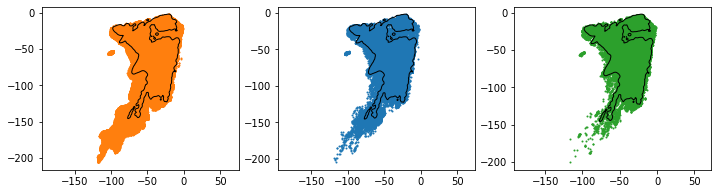

In [23]:
fig, ax = plt.subplots(figsize=(12,3),ncols=3)
for (a,c) in zip(ax,["male","female","pup"]):
    a.scatter(*fwb[fwb["class"].isin([c])][["x_m","y_m"]].values.T,s=1,color=colors[c])
    gpd.GeoSeries([mp_fwb]).plot(ax=a, 
                                 facecolor="none", 
                                 edgecolor="black", 
                                 linewidth=1)
    a.axis("equal")

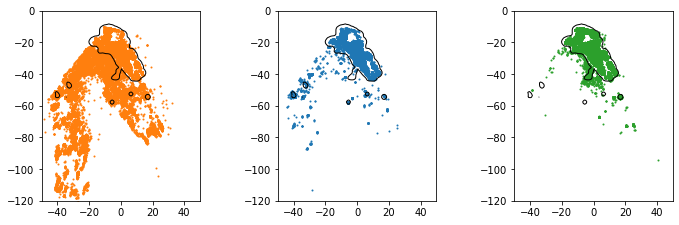

In [24]:
fig, ax = plt.subplots(figsize=(12,3.5),ncols=3)
for (a,c) in zip(ax,["male","female","pup"]):
    a.scatter(*ssb[ssb["class"].isin([c])][["x_m","y_m"]].values.T,s=1,color=colors[c])
    gpd.GeoSeries([mp_ssb]).plot(ax=a, 
                                 facecolor="none", 
                                 edgecolor="black", 
                                 linewidth=1)
    a.set_xlim(-50,50)
    a.set_ylim(-120,0)
#     a.axis("equal")
    

In [25]:


def add_voronoi_areas(
    df: pd.DataFrame,
    classes: List[str],
    x_col: str = "x_m",
    y_col: str = "y_m",
    time_col: str = "timestamp",
    class_col: str = "class",
) -> pd.DataFrame:
    """
    - Filters to df['class_name'].isin(classes)
    - Groups by `time_col`
    - Computes a 2D Voronoi on (x_col, y_col)
    - Returns df with a new float column 'voronoi_area' (NaN for infinite/invalid regions)
    """

    # 1) filter to only the classes you care about
    df2 = df[df[class_col].isin(classes)].copy()

    # 2) enable a progress bar on the groupby/apply
    tqdm.pandas()

    def _group_areas(group: pd.DataFrame) -> pd.DataFrame:
        pts = group[[x_col, y_col]].values

        # not enough points → all NaN
        if len(pts) < 3:
            areas = [np.nan] * len(group)
        else:
            try:
                vor = Voronoi(pts)
            except QhullError:
                areas = [np.nan] * len(group)
            else:
                areas = []
                for region_idx in vor.point_region:
                    verts = vor.regions[region_idx]
                    # infinite or empty region → NaN
                    if not verts or -1 in verts:
                        areas.append(np.nan)
                    else:
                        poly = Polygon(vor.vertices[verts])
                        areas.append(poly.area)

        out = group.copy()
        out["voronoi_area"] = areas
        return out

    # 3) group by timestamp with a tqdm progress bar
    result = (
        df2
        .groupby(time_col, group_keys=False)
        .progress_apply(_group_areas)
        .reset_index(drop=True)
    )
    return result

In [26]:
# --- precompute ---
vor_cache = {}

cases = [["male"], ["female"], ["pup"], ["male","female","pup"]]

for case in cases:
    # compute once and store
    vor_cache[("ssb", tuple(case))] = add_voronoi_areas(
        ssb_99.dropna(), classes=case
    )
    vor_cache[("fwb", tuple(case))] = add_voronoi_areas(
        fwb_99.dropna(), classes=case,
    )

  0%|          | 0/9734 [00:00<?, ?it/s]

  0%|          | 0/10046 [00:00<?, ?it/s]

  0%|          | 0/7879 [00:00<?, ?it/s]

  0%|          | 0/9712 [00:00<?, ?it/s]

  0%|          | 0/6319 [00:00<?, ?it/s]

  0%|          | 0/9008 [00:00<?, ?it/s]

  0%|          | 0/9781 [00:00<?, ?it/s]

  0%|          | 0/10046 [00:00<?, ?it/s]

Case ['male']: FWB Peak=2.27e-02, SSB Peak=4.40e-02, Ratio=1.94
Case ['female']: FWB Peak=1.24e-01, SSB Peak=6.11e-01, Ratio=4.94
Case ['pup']: FWB Peak=1.24e-01, SSB Peak=2.47e-01, Ratio=2.00
Case ['male', 'female', 'pup']: FWB Peak=2.73e-01, SSB Peak=1.07e+00, Ratio=3.94


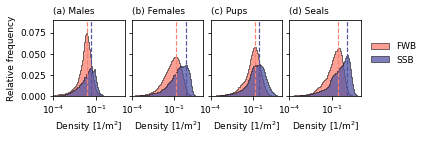

In [27]:
bins = np.logspace(np.log10(1e-5), np.log10(1e2), 100)

titles = ["(a) Males", "(b) Females", "(c) Pups", "(d) Seals"]

fig, axes = plt.subplots(1, len(cases), figsize=(5.9, 1.4), sharey=True, sharex=True)

# --- 2. Main Plotting Loop ---
for i, (ax, case) in enumerate(zip(axes, cases)):
    # Extract Data
    ssb_vor = vor_cache[("ssb", tuple(case))]
    fwb_vor = vor_cache[("fwb", tuple(case))]

    # Calculate Density (1 / Area)
    ssb_vals = 1 / ssb_vor.loc[ssb_vor['class'].isin(case), 'voronoi_area']
    fwb_vals = 1 / fwb_vor.loc[fwb_vor['class'].isin(case), 'voronoi_area']
    
    # --- Plot Histograms ---
    # FWB
    weights_fwb = np.ones_like(fwb_vals) / len(fwb_vals)
    ax.hist(fwb_vals, bins=bins, weights=weights_fwb, 
            label='FWB', color=colors["fwb"], edgecolor="black", 
            histtype='stepfilled', zorder=9, lw=0.7, alpha=0.75)
    
    # SSB
    weights_ssb = np.ones_like(ssb_vals) / len(ssb_vals)
    ax.hist(ssb_vals, bins=bins, weights=weights_ssb, 
            label='SSB', color=colors["ssb"], edgecolor="black", 
            histtype='stepfilled', zorder=10, lw=0.7, alpha=0.75)

    # --- Robust Peak Finding (KDE on Log Data) ---
    peak_locs = {}
    
    for label, vals, color in [("FWB", fwb_vals, colors["fwb"]), ("SSB", ssb_vals, colors["ssb"])]:
        if len(vals) > 1: # Ensure enough data for KDE
            # 1. Transform to log space (since x-axis is log)
            log_vals = np.log10(vals[vals>0])
            
            # 2. Fit Gaussian KDE
            kde = gaussian_kde(log_vals)
            
            # 3. Find max on a fine grid
            # Create a grid covering the plot range
            grid_log = np.linspace(np.log10(1e-5), np.log10(1e2), 1000)
            kde_y = kde(grid_log)
            peak_log = grid_log[np.argmax(kde_y)]
            
            # 4. Convert back to linear space
            true_peak = 10**peak_log
            peak_locs[label] = true_peak
            
            # 5. Plot the peak line
            ax.axvline(true_peak, color=color, linestyle='--', linewidth=1.2, zorder=15)
    
    # Print statistics for verification
    if "FWB" in peak_locs and "SSB" in peak_locs:
        ratio = peak_locs["SSB"] / peak_locs["FWB"]
        print(f"Case {case}: FWB Peak={peak_locs['FWB']:.2e}, SSB Peak={peak_locs['SSB']:.2e}, Ratio={ratio:.2f}")

    # --- Formatting ---
    ax.set_xscale('log')
    ax.set_title(titles[i], fontsize=9, loc="left")
    
    # X-Label only on bottom (handled by sharex, but good to be explicit)
    ax.set_xlabel(r"Density [$\mathrm{1/m^2}$]", fontsize=9)
    
    # Y-Label only on first plot
    if i == 0:
        ax.set_ylabel("Relative frequency", fontsize=9)
        
    ax.tick_params(axis="both", labelsize=9)
    
    # Set Limits
    ax.set_ylim(0, 0.09)
    ax.set_xlim(1e-4, 1.1e1)

# --- 3. Legend & Layout ---
# Create a single legend for the whole figure
# We grab handles from the first axis since they are identical across plots
handles, labels_ = axes[0].get_legend_handles_labels()

# Adjust layout to make room for the legend on the right
fig.subplots_adjust(right=0.85, wspace=0.1)

fig.legend(handles, labels_, 
           loc='center right',        
           bbox_to_anchor=(1., 0.55), # Fine-tune this x-value to move left/right
           frameon=False,             
           fontsize=9)

plt.savefig("figures/figure4.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

Case ['male']: FWB Peak=2.27e-02, SSB Peak=4.40e-02, Ratio=1.94
Case ['female']: FWB Peak=1.24e-01, SSB Peak=6.11e-01, Ratio=4.94
Case ['pup']: FWB Peak=1.24e-01, SSB Peak=2.47e-01, Ratio=2.00
Case ['male', 'female', 'pup']: FWB Peak=2.73e-01, SSB Peak=1.07e+00, Ratio=3.94


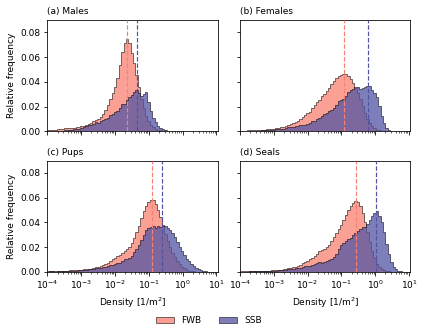

In [28]:
fontsize = 9
bins = np.logspace(np.log10(1e-5), np.log10(1e2), 100)
titles = ["(a) Males", "(b) Females", "(c) Pups", "(d) Seals"]

fig, axes = plt.subplots(2, 2, figsize=(5.9, 4.5), sharey=True, sharex=True)
axes = axes.flatten()

for i, (ax, case) in enumerate(zip(axes, cases)):
    ssb_vor = vor_cache[("ssb", tuple(case))]
    fwb_vor = vor_cache[("fwb", tuple(case))]
    ssb_vals = 1 / ssb_vor.loc[ssb_vor['class'].isin(case), 'voronoi_area']
    fwb_vals = 1 / fwb_vor.loc[fwb_vor['class'].isin(case), 'voronoi_area']

    weights_fwb = np.ones_like(fwb_vals) / len(fwb_vals)
    ax.hist(fwb_vals, bins=bins, weights=weights_fwb,
            label='FWB', color=colors["fwb"], edgecolor="black",
            histtype='stepfilled', zorder=9, lw=0.7, alpha=0.75)

    weights_ssb = np.ones_like(ssb_vals) / len(ssb_vals)
    ax.hist(ssb_vals, bins=bins, weights=weights_ssb,
            label='SSB', color=colors["ssb"], edgecolor="black",
            histtype='stepfilled', zorder=10, lw=0.7, alpha=0.75)

    peak_locs = {}
    for label, vals, color in [("FWB", fwb_vals, colors["fwb"]), ("SSB", ssb_vals, colors["ssb"])]:
        if len(vals) > 1:
            log_vals = np.log10(vals[vals > 0])
            kde = gaussian_kde(log_vals)
            grid_log = np.linspace(np.log10(1e-5), np.log10(1e2), 1000)
            kde_y = kde(grid_log)
            peak_log = grid_log[np.argmax(kde_y)]
            true_peak = 10**peak_log
            peak_locs[label] = true_peak
            ax.axvline(true_peak, color=color, linestyle='--', linewidth=1.2, zorder=15)

    if "FWB" in peak_locs and "SSB" in peak_locs:
        ratio = peak_locs["SSB"] / peak_locs["FWB"]
        print(f"Case {case}: FWB Peak={peak_locs['FWB']:.2e}, SSB Peak={peak_locs['SSB']:.2e}, Ratio={ratio:.2f}")

    ax.set_xscale('log')
    ax.set_title(titles[i], fontsize=fontsize, loc="left")
    ax.tick_params(axis="both", labelsize=fontsize)
    ax.set_ylim(0, 0.09)
    ax.set_xlim(1e-4, 1.1e1)

    # X-label only for bottom row
    if i >= 2:
        ax.set_xlabel(r"Density [$\mathrm{1/m^2}$]", fontsize=9)

    # Y-label only for left column
    if i % 2 == 0:
        ax.set_ylabel("Relative frequency", fontsize=9)

# Legend below the figure
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=2,
           frameon=False,
           fontsize=fontsize)

plt.tight_layout()
plt.savefig("figures/figure4_v2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

Freshwater Beach (FWB) A covered by B giant petrel 86.68974211829136
Freshwater Beach (FWB) A covered by B skua 79.2117035675417
Freshwater Beach (FWB) A covered by B sheathbill 94.24625326681964
Special Study Beach (SSB) A covered by B giant petrel 25.444653099820616
Special Study Beach (SSB) A covered by B skua 52.65272062108017
Special Study Beach (SSB) A covered by B sheathbill 99.28206960677524


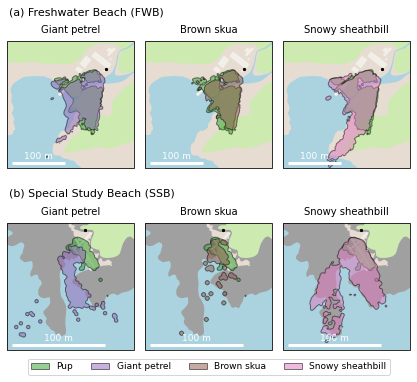

In [29]:
COLORS = {
    "background": "#A0A0A0",
    "water":      "#AAD3DF",
    "rocks":       "#A0A0A0",
    "vegetation": "#CDEBB0",
    "beach":      "#E6DCD2",
    "passway":    "#F2EFE9",
    "stream": "#AAD3DF",
    "building": "#F2EFE9",
    "jetty": "#F2EFE9"
}

ALPHA = 1
prob = 99
sigma = 1
resolution = 1

bird_columns = ["giant petrel", "skua", "sheathbill"]

# Datasets you want to render (add as many as you like)
DATASETS = [
    {"name": "both_areas", "png": "map/both_areas.png", "kml": "map/both_areas.kml", "cdb": "both_areas_v1.cdb"},
    {"name": "SSB", "png": "map/SSB.png", "kml": "map/SSB.kml", "cdb": "map/SSB_v1.cdb"},
    {"name": "FWB", "png": "map/FWB.png", "kml": "map/FWB.kml", "cdb": "map/FWB_v1.cdb"},
]
row_configs = [
    (fwb, "Freshwater Beach (FWB)", "x_m", "y_m", cam_fwb, DATASETS[2]),
    (ssb, "Special Study Beach (SSB)", "x_m", "y_m", cam_ssb, DATASETS[1])
]

# Increased figsize height slightly to accommodate the new row titles
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(5.9, 6), 
                        subplot_kw={'projection': ccrs.Mercator()})

for row_idx, (df, loc_label, x_col, y_col, cam, ge_dataset) in enumerate(row_configs):
    
    target_col = 'class' if 'class' in df.columns else 'class_name'
    
    # Calculate PUP KDE once per row
    pts = df[df[target_col]=="pup"][[x_col,y_col]].dropna().values
    xpup, ypup = pts[:,0], pts[:,1]
    
    H, Hs, lines, rings, mp = kde_outline_from_hist2d_v2(
        xpup, ypup,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

    for col_idx, bird_class in enumerate(bird_columns):
        ax = axs[row_idx, col_idx]
        
        # 1. Base Map
        if loc_label == "Freshwater Beach (FWB)":
            plot_ge_dataset(ge_dataset, ax, ["background", "beach","water", "rocks","vegetation","stream","building","passway"])
        else:
            plot_ge_dataset(ge_dataset, ax, ["background", "water", "rocks","beach","vegetation","passway"])
        
        # Scalebar
        add_scalebar(ax, 100, label='100 m', location='lower left', color="white")
        
        # Plot PUP KDE (Filled Region)
        ax.add_geometries(multipolygon_to_gps(cam, mp), crs=ccrs.PlateCarree(),
                          facecolor=colors["pup"], edgecolor="k", alpha=0.5, zorder=5)
        
        ax.scatter(cam.gps_lon, cam.gps_lat, c="k", transform=ccrs.PlateCarree(), zorder=5, s=5)
    
        # Plot Bird KDE
        bird_df = df[df[target_col] == bird_class]
        pts_bird = bird_df[[x_col,y_col]].dropna().values
        if len(pts_bird) > 0:
            x, y = pts_bird[:,0], pts_bird[:,1]
            Hbird, Hsbird, linesbird, ringsbird, mpbird = kde_outline_from_hist2d_v2(
                x, y,
                prob=prob,
                resolution=resolution,
                sigma=sigma,
                return_shapely=True
            )
            ax.add_geometries(multipolygon_to_gps(cam, mpbird), crs=ccrs.PlateCarree(),
                              facecolor=colors[bird_class], edgecolor="k", alpha=0.5, zorder=5)
            
            print(loc_label,'A covered by B',bird_class,overlap_percent(mp,mpbird,mode="of_a"))
        
        # Set Class Title for EVERY subplot (both rows)
        label_text = labels.get(bird_class, bird_class)
        formatted_label = label_text[0].upper() + label_text[1:]
        ax.set_title(formatted_label, fontsize=10, pad=8)

    # Add Row Titles: (a) for row 0, (b) for row 1
    row_prefix = "(a)" if row_idx == 0 else "(b)"
    fig.text(0.03, 0.9 if row_idx == 0 else 0.48, f"{row_prefix} {loc_label}", 
             ha='left', va='center', fontsize=11)
    


# Build legend handles
legend_handles = []
legend_handles.append(
    patches.Patch(facecolor=colors["pup"], edgecolor="k", alpha=0.5, label=labels["pup"].capitalize())
)
for bird_class in bird_columns:
    label_text = labels[bird_class]
    formatted_label = label_text[0].upper() + label_text[1:]
    legend_handles.append(
        patches.Patch(facecolor=colors[bird_class], edgecolor="k", alpha=0.5, label=formatted_label)
    )

# Add legend below the subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles),
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.05),
)
# Adjust layout to make room for fig.text titles
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figures/figure5.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()